ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df.drop('CUST_ID', axis=1, inplace=True)
print("CUST_ID column dropped.")
print("Remaining columns:", df.columns.tolist())

CUST_ID column dropped.
Remaining columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


**Check the missing values in each column.**

In [8]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
df.fillna(df.mean(), inplace=True)
print("Missing values filled with column means.")

Missing values filled with column means.


**Check the missing values again to make sure they were handled.**

In [10]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

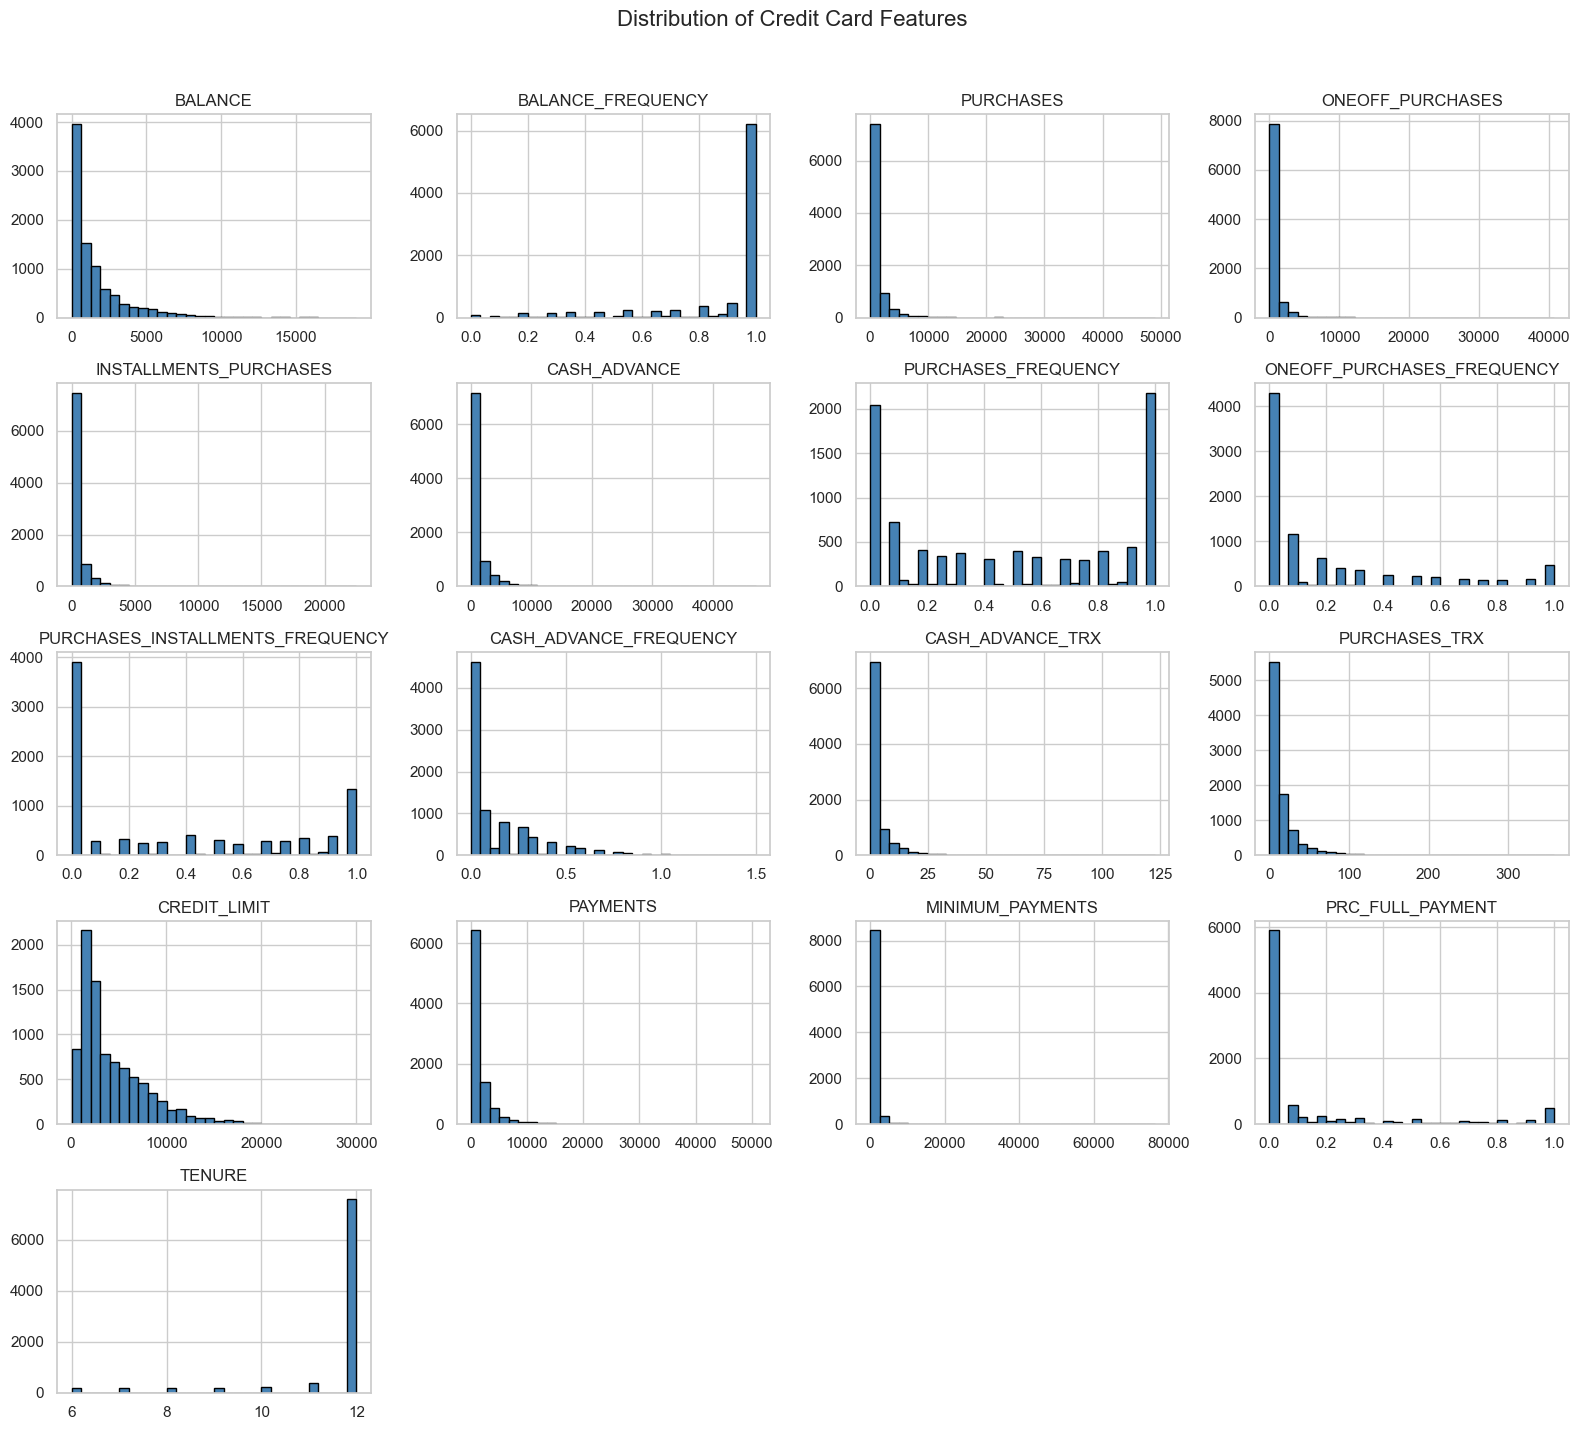

In [11]:
df.hist(figsize=(16, 14), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Credit Card Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

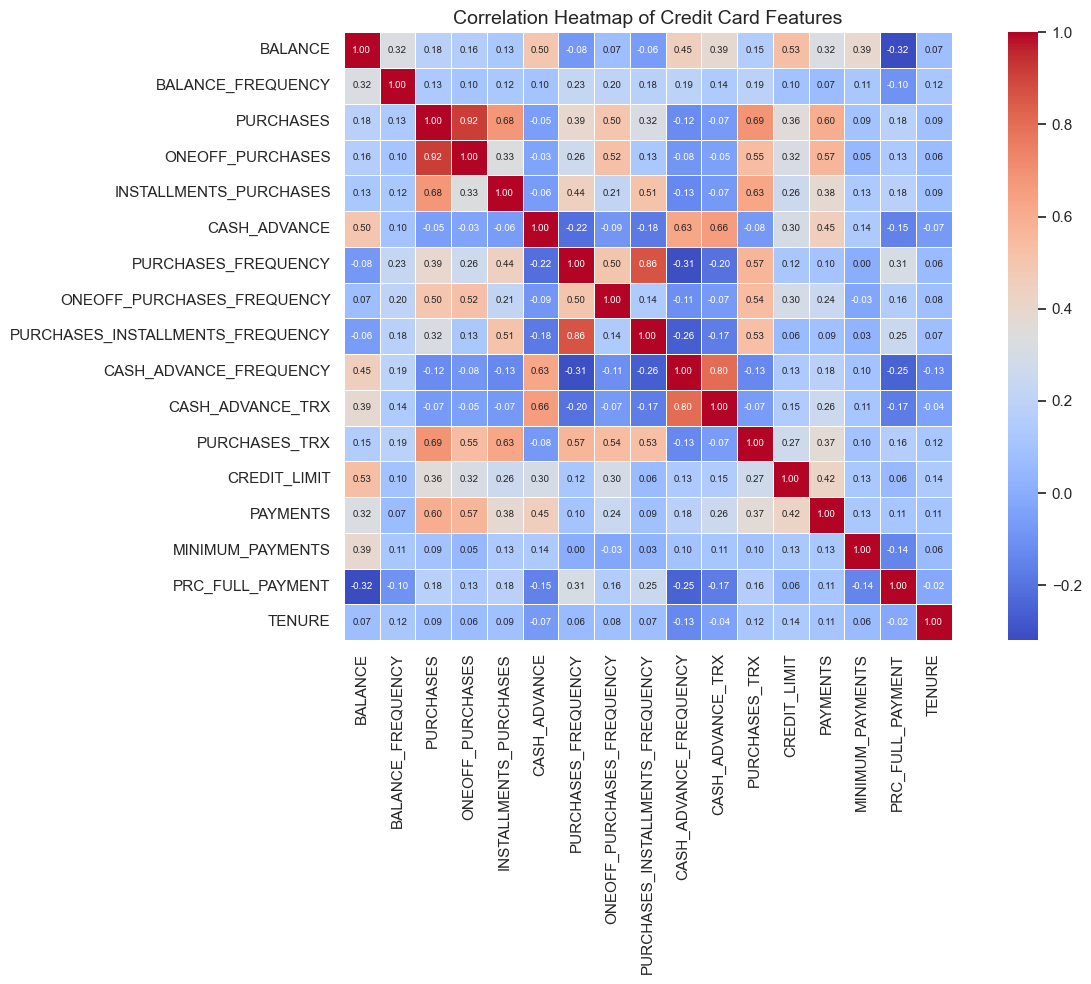

In [12]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={'size': 7})
plt.title('Correlation Heatmap of Credit Card Features', fontsize=14)
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

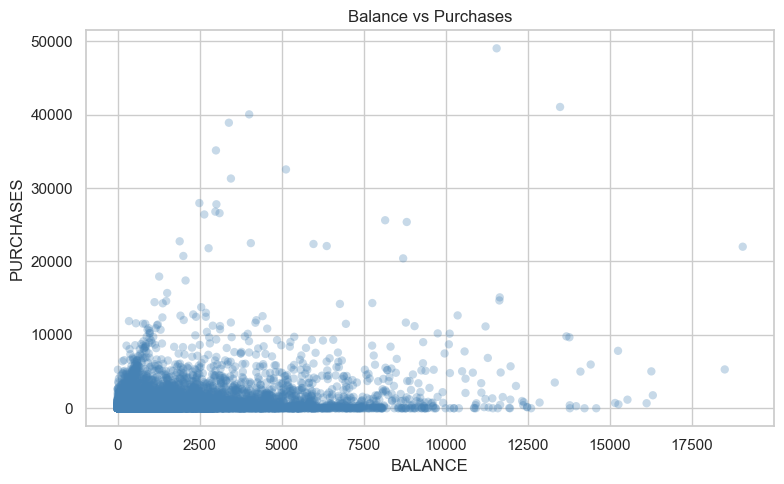

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('Balance vs Purchases')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

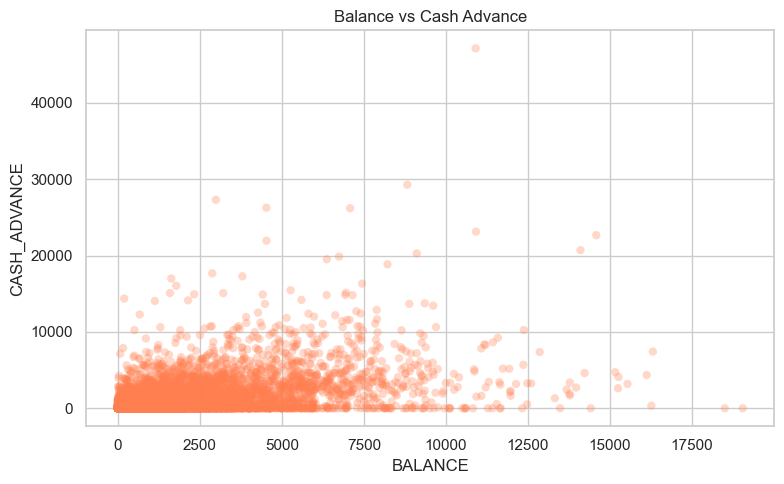

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='coral', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('Balance vs Cash Advance')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Data scaled successfully.")
print("Shape of X_scaled:", X_scaled.shape)

Data scaled successfully.
Shape of X_scaled: (8950, 17)


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print("Inertia values computed for K=1 to K=10.")

Inertia values computed for K=1 to K=10.


**Plot the elbow curve.**

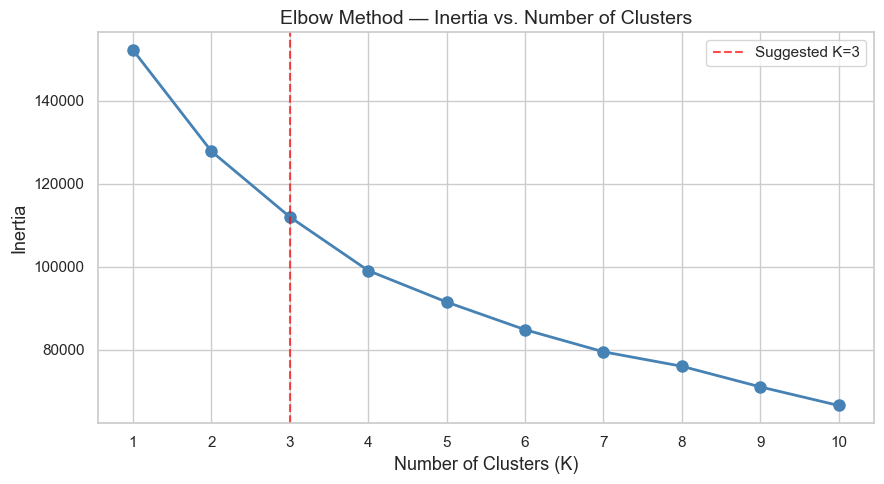

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inertia_values, marker='o', linewidth=2, color='steelblue', markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.title('Elbow Method — Inertia vs. Number of Clusters', fontsize=14)
plt.xticks(range(1, 11))
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Suggested K=3')
plt.legend()
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette scores computed for K=2 to K=10.")

Silhouette scores computed for K=2 to K=10.


**Plot the silhouette scores.**

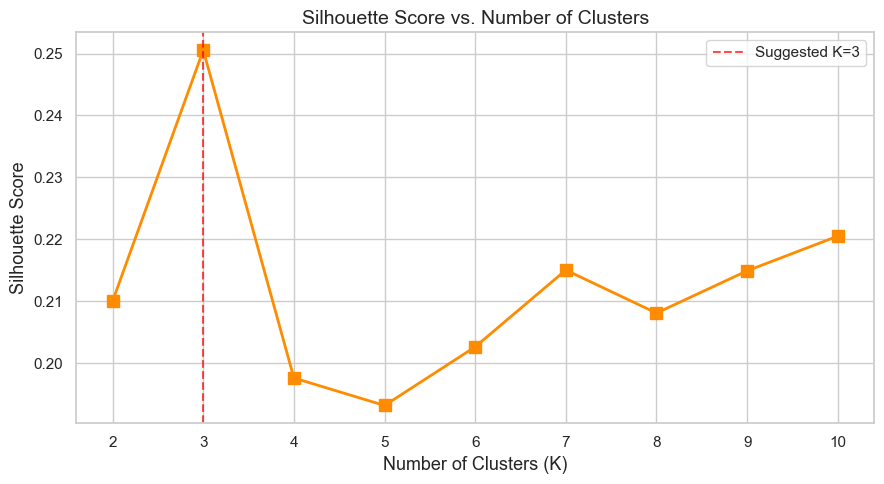

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), silhouette_scores, marker='s', linewidth=2, color='darkorange', markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14)
plt.xticks(range(2, 11))
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Suggested K=3')
plt.legend()
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
silhouette_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
silhouette_df.set_index('K', inplace=True)
print(silhouette_df.to_string())

    Silhouette Score
K                   
2             0.2100
3             0.2506
4             0.1976
5             0.1932
6             0.2026
7             0.2150
8             0.2081
9             0.2149
10            0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
# K=3 is chosen based on:
# - The elbow curve shows the largest "bend" around K=3
# - K=3 has the highest silhouette score (0.2506) among all tested values
# - 3 segments is also a practical and interpretable number for marketing

final_k = 3
final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

print(f"Final K-Means model trained with K={final_k}")
print(f"Final inertia: {final_kmeans.inertia_:.2f}")

Final K-Means model trained with K=3
Final inertia: 111986.70


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
df['Cluster'] = final_kmeans.labels_
print("Cluster labels added to dataframe.")

Cluster labels added to dataframe.


**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
cluster_summary = df.groupby('Cluster').mean().round(2)
print("Cluster Summary (Mean Values):")
cluster_summary

Cluster Summary (Mean Values):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3989.33,0.96,384.53,248.72,135.89,3869.86,0.23,0.11,0.14,0.45,12.39,5.61,6682.96,3018.91,1795.69,0.03,11.35
1,2220.00,0.98,4268.52,2717.83,1551.18,458.42,0.95,0.67,0.74,0.06,1.53,56.47,7733.97,4151.28,1224.54,0.30,11.92
2,799.70,0.84,505.53,253.12,252.73,329.87,0.47,0.13,0.35,0.07,1.21,8.65,3269.79,909.73,548.53,0.16,11.48


**Check how many customers are in each cluster.**

Number of customers per cluster:
Cluster
0    1596
1    1235
2    6119
Name: count, dtype: int64


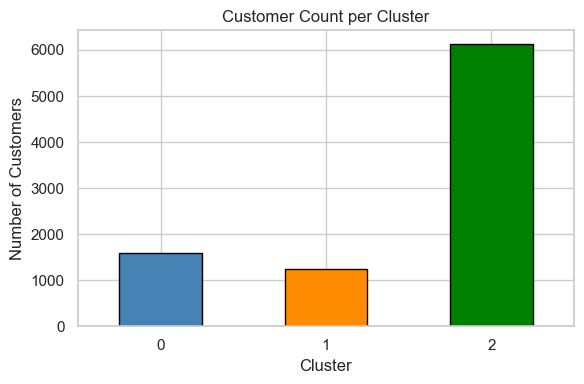

In [25]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Number of customers per cluster:")
print(cluster_counts)

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind='bar', color=['steelblue', 'darkorange', 'green'], edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Count per Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

Explained variance by PC1: 27.29%
Explained variance by PC2: 20.30%
Total explained variance: 47.59%


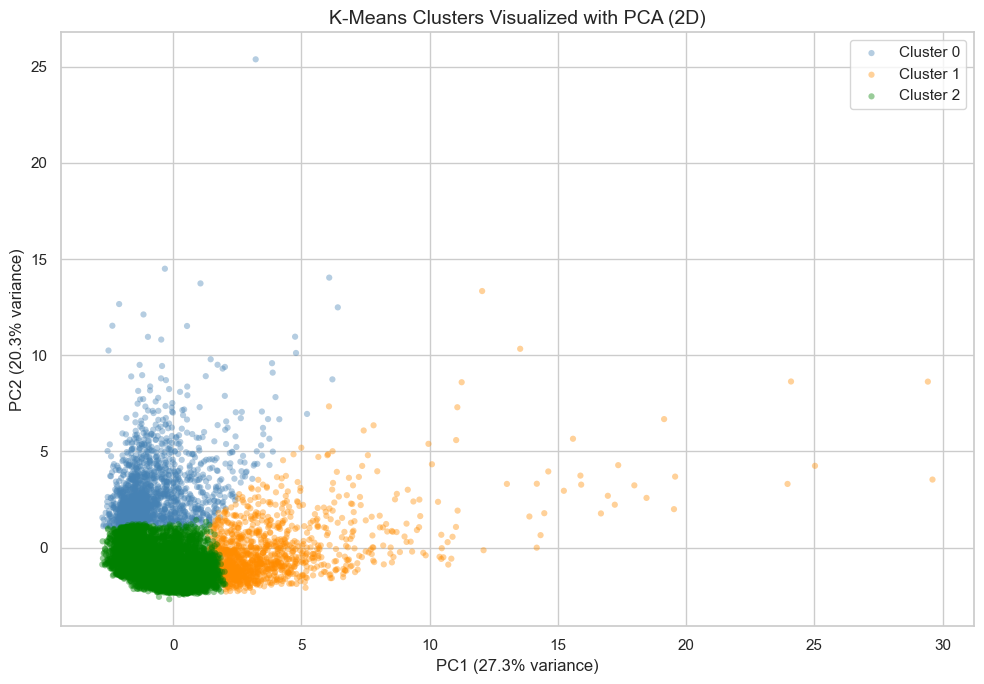

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")
print(f"Total explained variance: {sum(explained_variance):.2%}")

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

colors = ['steelblue', 'darkorange', 'green']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(10, 7))
for i, (color, label) in enumerate(zip(colors, labels)):
    subset = pca_df[pca_df['Cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], c=color, label=label, alpha=0.4, s=20, edgecolors='none')

plt.xlabel(f'PC1 ({explained_variance[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%} variance)', fontsize=12)
plt.title('K-Means Clusters Visualized with PCA (2D)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?

2. Why did we remove the `CUST_ID` column?

3. Which columns had missing values?

4. How did you handle the missing values?

5. Why is scaling important before applying K-Means?

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.

7. Based on the cluster summary table, describe each customer segment in your own words.

8. Which cluster may represent high-value customers?

9. Which cluster may represent customers who rely more on cash advance?

10. How can a company use these clusters for marketing strategy?

### Answers

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain a pre-defined target label (i.e., there is no column telling us which group each customer belongs to). We let the algorithm discover hidden patterns and natural groupings in the data without any guidance.

---

**2. Why did we remove the `CUST_ID` column?**

`CUST_ID` is just an identifier — it is a unique label assigned to each customer for tracking purposes and carries no information about customer behavior. Including it would introduce meaningless variation and confuse the clustering algorithm.

---

**3. Which columns had missing values?**

- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

---

**4. How did you handle the missing values?**

We used **mean imputation**: we filled each missing value with the mean of its column (`df.fillna(df.mean(), inplace=True)`). This is a simple and commonly used strategy that preserves the overall distribution of the data.

---

**5. Why is scaling important before applying K-Means?**

K-Means calculates the **Euclidean distance** between data points to assign them to clusters. If features have very different ranges (e.g., `CREDIT_LIMIT` in thousands vs. `PURCHASES_FREQUENCY` between 0 and 1), the algorithm will be dominated by the large-scale features and will largely ignore the small-scale ones. StandardScaler transforms all features to have a mean of 0 and a standard deviation of 1, ensuring every feature contributes equally to the distance calculations.

---

**6. Which K value did you choose? Explain your answer.**

We chose **K = 3** based on two criteria:

- **Elbow Method**: The inertia curve shows the sharpest decline between K=1 and K=3. After K=3, the rate of decrease slows significantly, suggesting diminishing returns from adding more clusters.
- **Silhouette Score**: K=3 achieved the highest silhouette score of **0.2506** among all values tested (K=2 to K=10), indicating the best separation and cohesion of clusters.

Additionally, 3 segments is an interpretable and actionable number for a business marketing team.

---

**7. Describe each customer segment based on the cluster summary table.**

**Cluster 0** — Cash Advance Users (1,596 customers): These customers have the highest balance ($3,989 avg) and rely heavily on cash advance ($3,869 avg, taken ~12 times on average). Their purchase frequency is very low (0.23) and they almost never pay in full (only 3%). They use the credit card mainly as a borrowing tool rather than for shopping.

**Cluster 1** — Active High Spenders (1,235 customers): These customers make by far the most purchases ($4,268 avg across ~56 transactions). They have the highest credit limit ($7,734) and make large payments ($4,151 avg). They pay in full 30% of the time, making them the most creditworthy and financially engaged segment.

**Cluster 2** — Low Activity / Dormant Customers (6,119 customers): This is the largest group. These customers have low balances ($799), low purchases ($505), and very little cash advance ($329). Their credit limit is also the lowest ($3,269). They appear to use their credit card infrequently and are mostly inactive.

---

**8. Which cluster may represent high-value customers?**

**Cluster 1** likely represents high-value customers, as they have high purchase volumes, high credit limits, and consistent payment behavior. These customers are the most financially engaged and profitable for the company.

---

**9. Which cluster may represent customers who rely more on cash advance?**

**Cluster 0** represents customers who rely most heavily on cash advance. Their average cash advance amount is $3,869, taken approximately 12 times (CASH_ADVANCE_TRX = 12.39), with a cash advance frequency of 0.45 — far higher than **Cluster 1** (0.06) and **Cluster 2** (0.07). Despite carrying the highest balances, they make very few purchases, showing that their card usage is almost entirely for cash borrowing.


---

**10. How can a company use these clusters for marketing strategy?**

- **Cluster 0 (Cash Advance Users)**: Offer debt consolidation products, lower-interest installment plans, or financial counseling services. These customers carry high balances and borrow frequently, so the company could help them restructure their debt while reducing financial risk.
- **Cluster 1 (Active High Spenders)**: Reward and retain these valuable customers with loyalty programs, cashback offers, travel benefits, or premium credit card upgrades. They spend heavily and pay reliably, making them the most profitable segment.
- **Cluster 2 (Dormant / Low Activity)**: Run re-engagement campaigns with personalized incentives such as bonus points, limited-time discounts, or low-interest offers to encourage more active card usage. Since this is the largest group (6,119 customers), even a small increase in engagement would have a significant business impact.